## Load Libreries

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score ,KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression , RidgeCV , LassoCV
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.dummy import DummyRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import clone
import joblib

## Load the data 

In [2]:
df = pd.read_csv("..\\DATA\\RAW DATA\\Ames_Housing_Data.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   str    
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   str    
 6   Alley            198 non-null    str    
 7   Lot Shape        2930 non-null   str    
 8   Land Contour     2930 non-null   str    
 9   Utilities        2930 non-null   str    
 10  Lot Config       2930 non-null   str    
 11  Land Slope       2930 non-null   str    
 12  Neighborhood     2930 non-null   str    
 13  Condition 1      2930 non-null   str    
 14  Condition 2      2930 non-null   str    
 15  Bldg Type        2930 non-null   str    
 16  House Style      2930 non-null   str    
 17  Overall Qual     2930 non

In [4]:
df.columns

Index(['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

## Outlier Detection

### Since this is public housing transaction data and we don't have direct insight into the government's data collection or sales process, we lack strong domain knowledge to flag outliers based on business rules alone. As a result, we'll rely primarily on statistical and visual methods — such as scatter plots against SalePrice, IQR/Z-score thresholds, and residual analysis after an initial model fit — to identify observations that deviate significantly from the overall pattern.

In [5]:
df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


<Axes: >

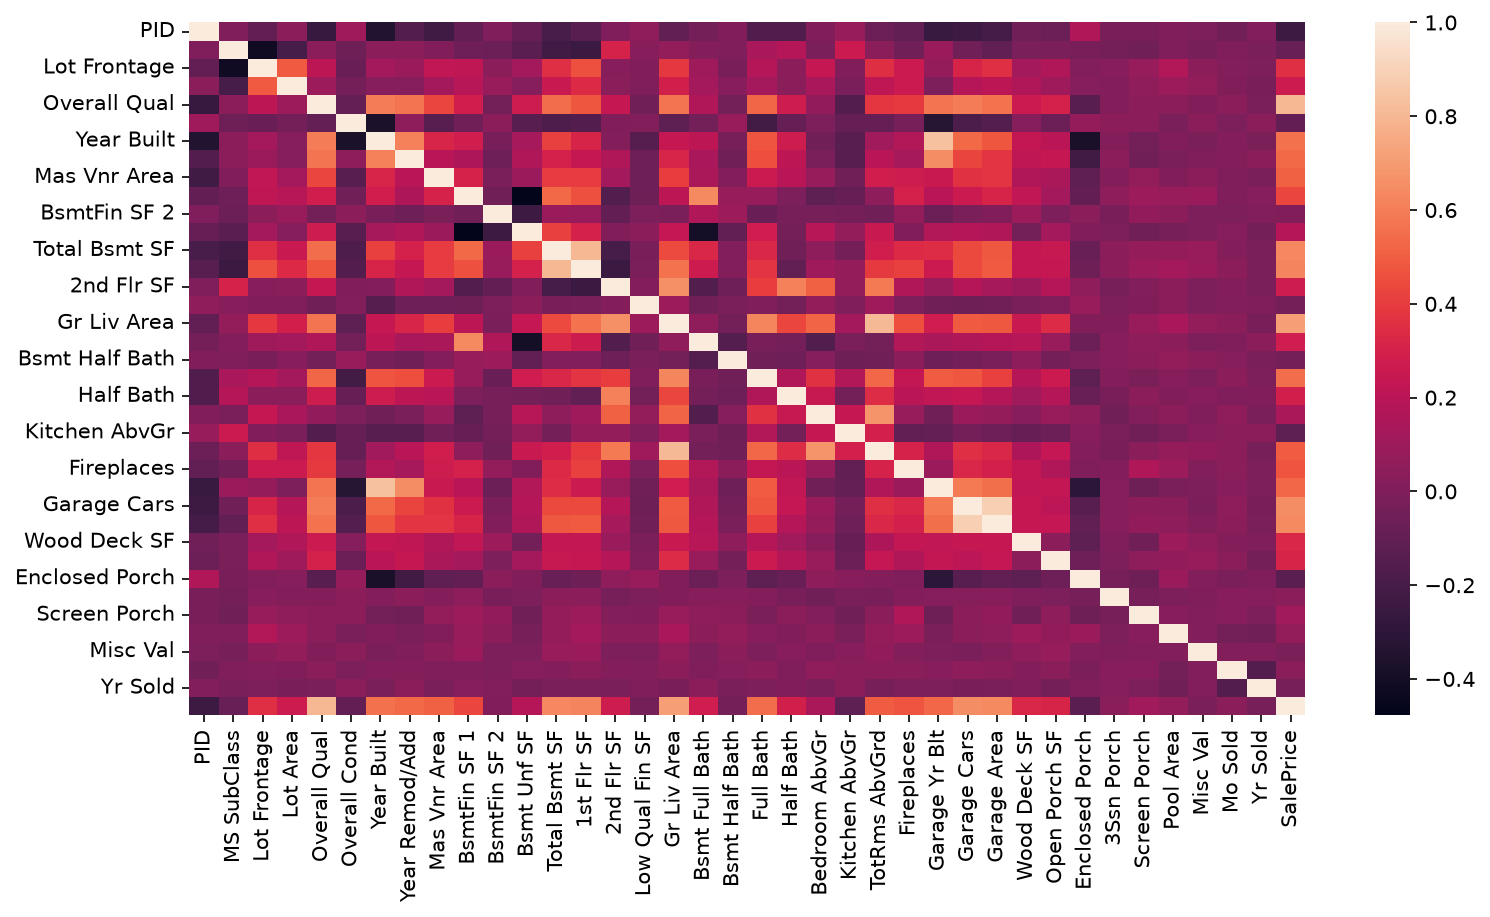

In [6]:
plt.figure(figsize=(12,6),dpi=150)
sns.heatmap(data=df.corr(numeric_only=True))

In [7]:
df.corr(numeric_only=True)['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

<Figure size 2400x1200 with 0 Axes>

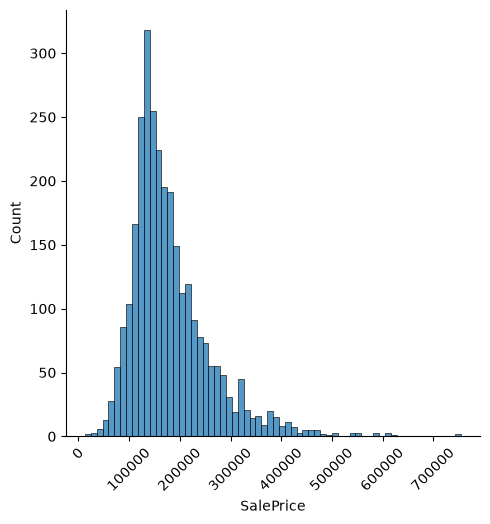

In [8]:
plt.figure(figsize=(12,6),dpi=200)
sns.displot(data=df,x='SalePrice')
plt.xticks(rotation=45);

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

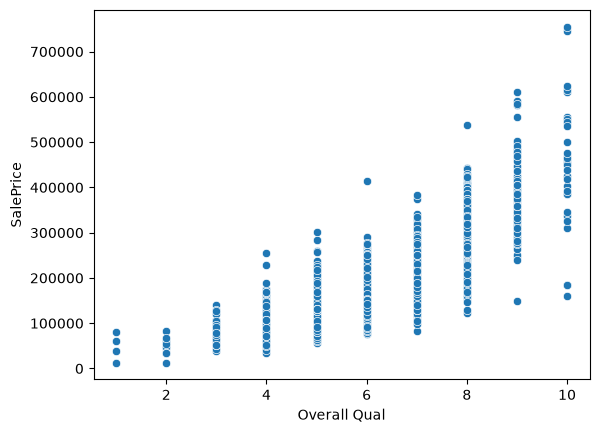

In [9]:
sns.scatterplot(data=df,x='Overall Qual',y='SalePrice')

### The scatter plot of SalePrice against Overall Qual shows the expected strong positive relationship — as overall quality increases, sale price rises accordingly. However, we can identify a small number of exceptions to this trend: two houses rated Overall Qual = 9 and one rated Overall Qual = 10 sold for prices well below what their quality tier would predict, sitting closer to the price range of homes rated 5–6. These points stand out as clear outliers and warrant closer inspection — checking features like Sale Condition and Gr Liv Area for these specific rows should help explain the discrepancy (e.g. a foreclosure, partial sale, or data entry error) before deciding whether to remove or retain them.

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

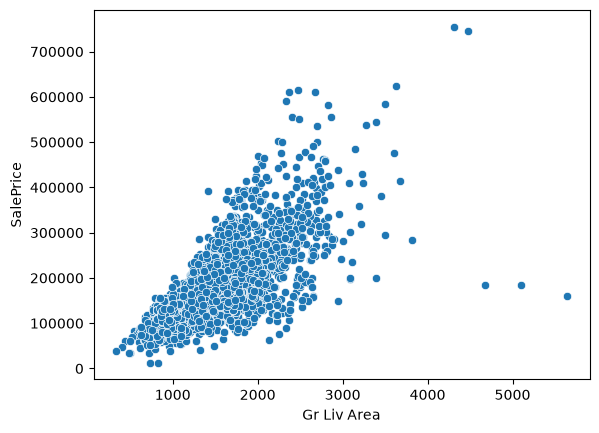

In [10]:
sns.scatterplot(data=df , x = 'Gr Liv Area', y = 'SalePrice')

In [11]:
df[(df['Overall Qual'] > 8) & (df['SalePrice'] < 200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [12]:
df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 400000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


## Handling Outliers

### Cross-referencing our two outlier checks — high Overall Qual with unusually low SalePrice, and unusually large Gr Liv Area with low SalePrice — we find that the same three houses (indices 1498, 2180, 2181) appear in both cases. All three have Sale Condition = Partial, meaning they were new-construction homes that hadn't been fully assessed at the time of sale, which likely explains the mismatch between their size/quality and their recorded price.

### Since these observations don't reflect typical market behavior and could distort the linear relationship our model is trying to learn, we treat them as outliers and drop them from the training data.

In [13]:
ind_drop = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 400000)].index

In [14]:
df = df.drop(ind_drop,axis=0)

In [15]:
df.shape

(2927, 81)

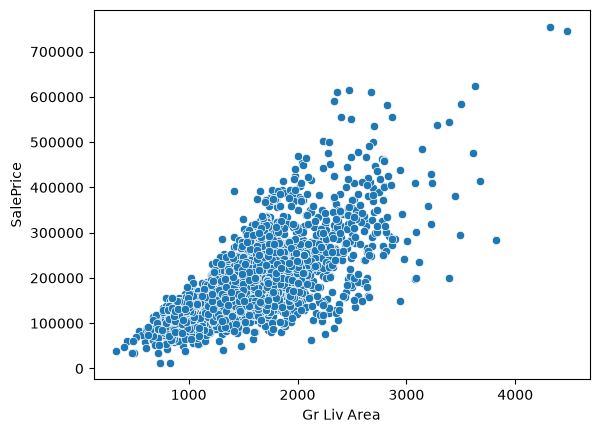

In [16]:
sns.scatterplot(x='Gr Liv Area',y='SalePrice',data=df);

sns.scatterplot(x='Overall Qual',y='SalePrice',data=df);

# Handling Missing Values

## PID suppresion

# we allredy have index so there is no need for this column

In [17]:
df = df.drop('PID',axis=1)

In [18]:
len(df.columns)

80

## observation of nan features

In [19]:
df.isnull()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2926,False,False,True,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2927,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [20]:
df.isnull().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      490
Lot Area            0
Street              0
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 80, dtype: int64

In [21]:
100* df.isnull().sum() / len(df)

MS SubClass        0.00000
MS Zoning          0.00000
Lot Frontage      16.74069
Lot Area           0.00000
Street             0.00000
                    ...   
Mo Sold            0.00000
Yr Sold            0.00000
Sale Type          0.00000
Sale Condition     0.00000
SalePrice          0.00000
Length: 80, dtype: float64

In [22]:
def percent_missing(df):
    percent_nan = 100*df.isnull().sum() / len(df)
    percent_nan = percent_nan[percent_nan>0].sort_values()
    return percent_nan

In [23]:
percent_nan = percent_missing(df)

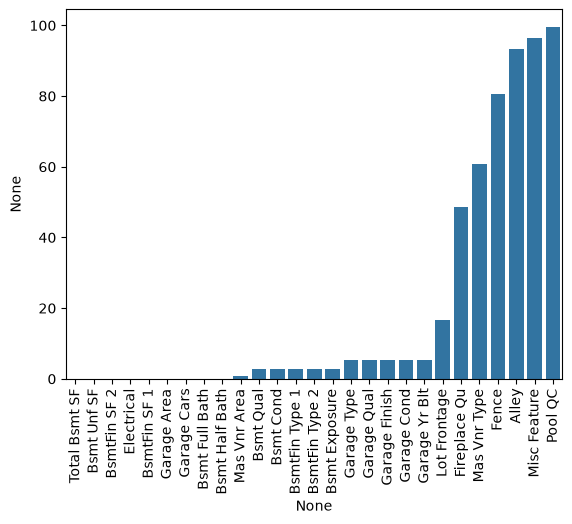

In [24]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

## fills the null values

In [25]:
percent_nan[percent_nan < 1]

Total Bsmt SF     0.034165
Bsmt Unf SF       0.034165
BsmtFin SF 2      0.034165
Electrical        0.034165
BsmtFin SF 1      0.034165
Garage Area       0.034165
Garage Cars       0.034165
Bsmt Full Bath    0.068329
Bsmt Half Bath    0.068329
Mas Vnr Area      0.785787
dtype: float64

In [26]:
100 / len(df)

0.0341646737273659

In [27]:
(0.034165/100)*len(df)

1.00000955

In [28]:
df[df['Total Bsmt SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [29]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [30]:
bsmt_num_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

In [31]:
bsmt_str_cols =  ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
df[bsmt_str_cols] = df[bsmt_str_cols].fillna('None')

In [32]:
percent_nan = percent_missing(df)

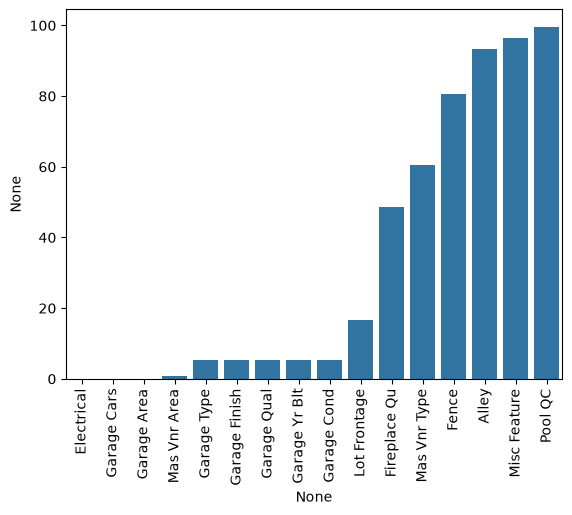

In [33]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

## Removing Rows

For a few of these features, it looks like only one or two rows of data are missing. Based on our .txt dataset description file, we could also easily fill in these data points, and that would be the more correct approach. But here we'll show how to drop them instead, in case you find yourself in a situation where it makes more sense to get rid of a row based on missing column features.

In [34]:
df = df.dropna(axis=0,subset= ['Electrical','Garage Cars'])

In [35]:
percent_nan = percent_missing(df)

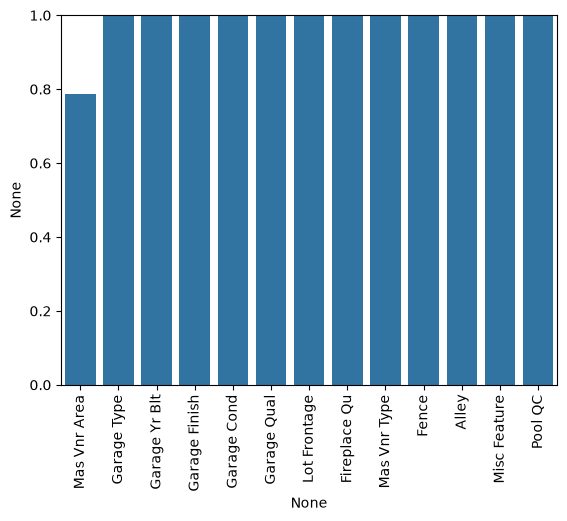

In [36]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);
plt.ylim(0,1);

## Features "Mas Vnr"

Based on the text description file, the fact that Mas Vnr Type and Mas Vnr Area are missing (NaN) most likely means the house simply doesn't have a masonry veneer, in which case we'll fill in this data the same way we did before.

In [37]:
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

In [38]:
percent_nan = percent_missing(df)

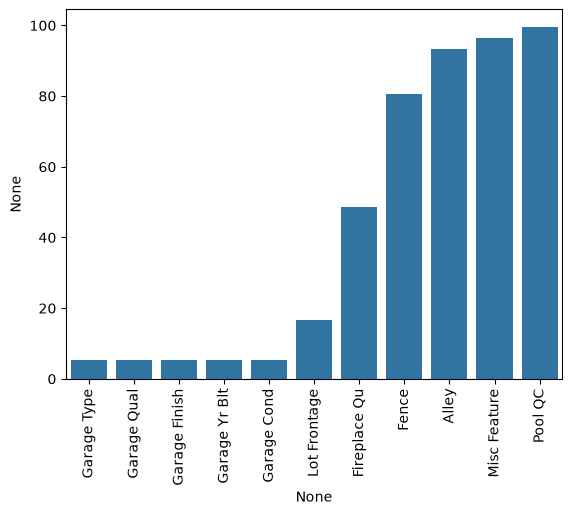

In [39]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

## Filling in Missing Column Data

Our previous approaches were more focused on missing data at the row level. We'll now shift to an approach based on the column features themselves, since a larger percentage of data appears to be missing there.

# Garage Column

Based on the data description, these NaNs appear to indicate the absence of a garage, so we'll fill them with "None" or 0.

In [40]:
df[['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']]

,Garage Type,Garage Finish,Garage Qual,Garage Cond
0,Attchd,Fin,TA,TA
1,Attchd,Unf,TA,TA
2,Attchd,Unf,TA,TA
3,Attchd,Fin,TA,TA
4,Attchd,Fin,TA,TA
...,...,...,...,...
2925,Detchd,Unf,TA,TA
2926,Attchd,Unf,TA,TA
2927,NaN,NaN,NaN,NaN
2928,Attchd,RFn,TA,TA


In [41]:
gar_str_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
df[gar_str_cols] = df[gar_str_cols].fillna('None')

In [42]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [43]:
percent_nan = percent_missing(df)

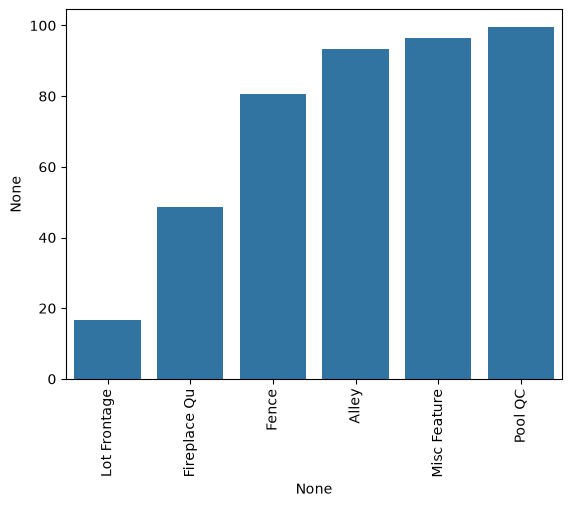

In [44]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

In [45]:
df = df.drop(['Pool QC','Misc Feature','Alley','Fence'],axis=1)

In [46]:
percent_nan = percent_missing(df)

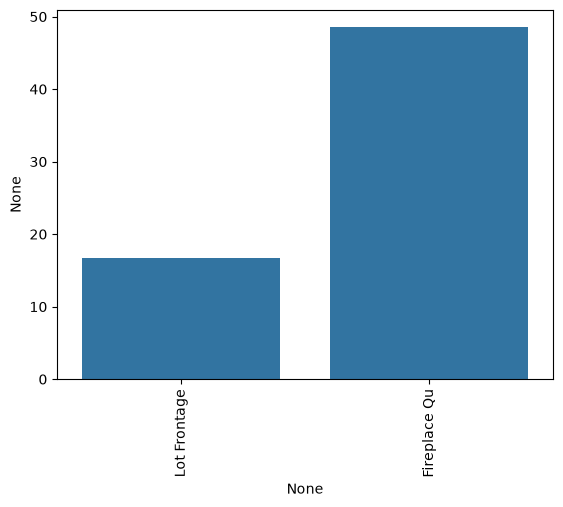

In [47]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

In [48]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna("None")

In [49]:
percent_nan = percent_missing(df)

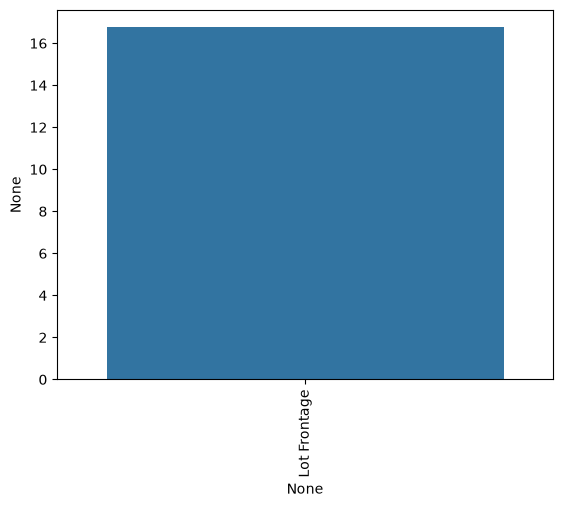

In [50]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

# [Imputation](https://en.wikipedia.org/wiki/Imputation_(statistics))of Missing Data


To impute the missing data, we need to decide which other well-populated feature (no NaN values) is most correlated with the feature that's missing data. In this particular case, we'll use:

"Neighborhood": Physical locations (neighborhoods) within Ames city limits

"Lot Frontage": Linear feet of street connected to the property

We're operating on the assumption that Lot Frontage is related to the Neighborhood the house is located in.

In [51]:
df['Neighborhood'].unique()

<ArrowStringArray>
[  'NAmes', 'Gilbert', 'StoneBr',  'NWAmes', 'Somerst',  'BrDale', 'NPkVill',
 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW',  'Sawyer',  'Greens', 'BrkSide',
 'OldTown',  'IDOTRR', 'ClearCr',   'SWISU', 'Edwards', 'CollgCr', 'Crawfor',
 'Blueste', 'Mitchel',  'Timber', 'MeadowV', 'Veenker', 'GrnHill', 'Landmrk']
Length: 28, dtype: str

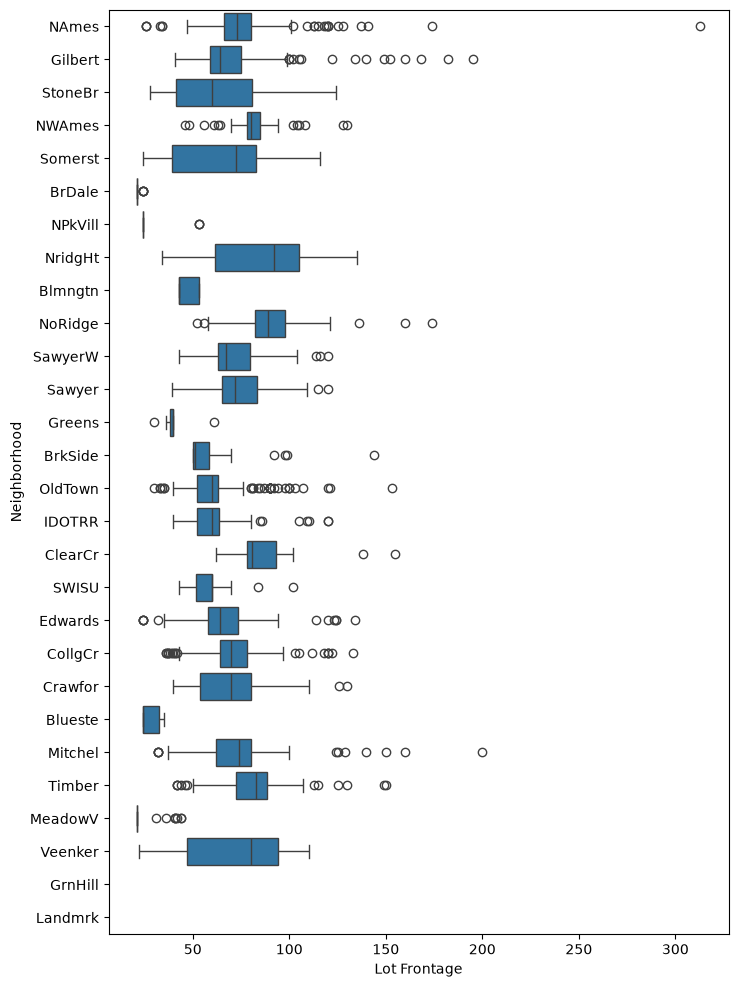

In [52]:
plt.figure(figsize=(8,12))
sns.boxplot(x='Lot Frontage',y='Neighborhood',data=df,orient='h');

In [53]:
df.groupby('Neighborhood')['Lot Frontage']

In [54]:
df.groupby('Neighborhood')['Lot Frontage'].mean()

Neighborhood
Blmngtn    46.900000
Blueste    27.300000
BrDale     21.500000
BrkSide    55.789474
ClearCr    88.150000
CollgCr    71.336364
Crawfor    69.951807
Edwards    64.794286
Gilbert    74.207207
Greens     41.000000
GrnHill          NaN
IDOTRR     62.383721
Landmrk          NaN
MeadowV    25.606061
Mitchel    75.144444
NAmes      75.210667
NPkVill    28.142857
NWAmes     81.517647
NoRidge    91.629630
NridgHt    84.184049
OldTown    61.777293
SWISU      59.068182
Sawyer     74.551020
SawyerW    70.669811
Somerst    64.549383
StoneBr    62.173913
Timber     81.303571
Veenker    72.000000
Name: Lot Frontage, dtype: float64

In [55]:
df.head()['Lot Frontage']

0    141.0
1     80.0
2     81.0
3     93.0
4     74.0
Name: Lot Frontage, dtype: float64

In [56]:
df[df['Lot Frontage'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
11,20,RL,NaN,7980,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,500,3,2010,WD,Normal,185000
14,120,RL,NaN,6820,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,140,0,0,6,2010,WD,Normal,212000
22,60,FV,NaN,7500,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,1,2010,WD,Normal,216000
23,20,RL,NaN,11241,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,700,3,2010,WD,Normal,149000
24,20,RL,NaN,12537,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,149900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2894,20,RL,NaN,16669,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,1,2006,WD,Normal,228000
2897,60,RL,NaN,11170,Pave,IR2,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2006,WD,Normal,250000
2898,20,RL,NaN,8098,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,10,2006,WD,Normal,202000
2912,90,RL,NaN,11836,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,3,2006,WD,Normal,146500


In [57]:
df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean()))

0       141.000000
1        80.000000
2        81.000000
3        93.000000
4        74.000000
           ...    
2925     37.000000
2926     75.144444
2927     62.000000
2928     77.000000
2929     74.000000
Name: Lot Frontage, Length: 2925, dtype: float64

In [58]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean()))

In [59]:
percent_nan = percent_missing(df)

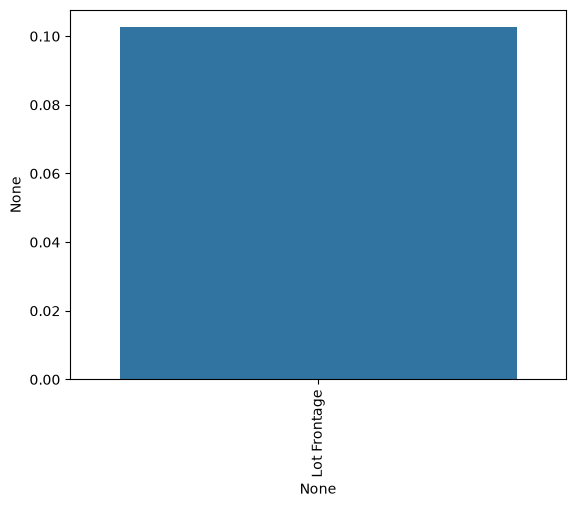

In [60]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

In [61]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

In [62]:
percent_nan = percent_missing(df)

In [63]:
percent_nan

Series([], dtype: float64)

## Categorical Data


Many Machine Learning models can't process categorical datasets with string values. For example, linear regression can't apply a beta coefficient to colors like "red" or "blue". Instead, we need to convert these categories into "dummy" variables, otherwise known as "one-hot" encoding.

In [64]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [65]:
df.select_dtypes(include= object)

C:\Users\hp\AppData\Local\Temp\ipykernel_26872\1481617184.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include= object)


,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,TA,Typ,Gd,Attchd,Fin,TA,TA,P,WD,Normal
1,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,...,TA,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal
3,RL,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
4,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,...,TA,Typ,None,Detchd,Unf,TA,TA,Y,WD,Normal
2926,RL,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,...,TA,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal
2927,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,...,TA,Typ,None,None,None,None,None,Y,WD,Normal
2928,RL,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [66]:
df.info()

<class 'pandas.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   int64  
 1   MS Zoning        2925 non-null   str    
 2   Lot Frontage     2925 non-null   float64
 3   Lot Area         2925 non-null   int64  
 4   Street           2925 non-null   str    
 5   Lot Shape        2925 non-null   str    
 6   Land Contour     2925 non-null   str    
 7   Utilities        2925 non-null   str    
 8   Lot Config       2925 non-null   str    
 9   Land Slope       2925 non-null   str    
 10  Neighborhood     2925 non-null   str    
 11  Condition 1      2925 non-null   str    
 12  Condition 2      2925 non-null   str    
 13  Bldg Type        2925 non-null   str    
 14  House Style      2925 non-null   str    
 15  Overall Qual     2925 non-null   int64  
 16  Overall Cond     2925 non-null   int64  
 17  Year Built       2925 non-null

## Numerical to Categorical Column

We need to be careful when it comes to encoding categories as numbers. We want to make sure the numerical relationship actually makes sense to a model. For example, the encoding of "MSSubClass" is essentially a numeric code per class:

MSSubClass: Identifies the type of dwelling involved in the sale.   

    20  1-STORY 1946 & NEWER ALL STYLES
    30  1-STORY 1945 & OLDER
    40  1-STORY W/FINISHED ATTIC ALL AGES
    45  1-1/2 STORY - UNFINISHED ALL AGES
    50  1-1/2 STORY FINISHED ALL AGES
    60  2-STORY 1946 & NEWER
    70  2-STORY 1945 & OLDER
    75  2-1/2 STORY ALL AGES
    80  SPLIT OR MULTI-LEVEL
    85  SPLIT FOYER
    90  DUPLEX - ALL STYLES AND AGES
    120  1-STORY PUD (Planned Unit Development) - 1946 & NEWER
    150  1-1/2 STORY PUD - ALL AGES
    160  2-STORY PUD - 1946 & NEWER
    180  PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
    190  2 FAMILY CONVERSION - ALL STYLES AND AGES

The number doesn't seem to have any relationship to the other numbers. If 30 > 20 is true, it doesn't really make sense that "1-STORY 1945 & OLDER" > "1-STORY 1946 & NEWER ALL STYLES". Keep in mind that this isn't always the case — for example, 1st class seats vs. 2nd class seats encoded with the numbers 1 and 2. Make sure you have a good understanding of your dataset to examine what needs to be converted/changed.

In [67]:
df['MS SubClass'] = df['MS SubClass'].apply(str)

In [68]:
df_nums = df.select_dtypes(exclude='object')
df_objs = df.select_dtypes(include='object')

C:\Users\hp\AppData\Local\Temp\ipykernel_26872\4271088617.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_objs = df.select_dtypes(include='object')


In [69]:
df_nums.info()

<class 'pandas.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Lot Frontage     2925 non-null   float64
 1   Lot Area         2925 non-null   int64  
 2   Overall Qual     2925 non-null   int64  
 3   Overall Cond     2925 non-null   int64  
 4   Year Built       2925 non-null   int64  
 5   Year Remod/Add   2925 non-null   int64  
 6   Mas Vnr Area     2925 non-null   float64
 7   BsmtFin SF 1     2925 non-null   float64
 8   BsmtFin SF 2     2925 non-null   float64
 9   Bsmt Unf SF      2925 non-null   float64
 10  Total Bsmt SF    2925 non-null   float64
 11  1st Flr SF       2925 non-null   int64  
 12  2nd Flr SF       2925 non-null   int64  
 13  Low Qual Fin SF  2925 non-null   int64  
 14  Gr Liv Area      2925 non-null   int64  
 15  Bsmt Full Bath   2925 non-null   float64
 16  Bsmt Half Bath   2925 non-null   float64
 17  Full Bath        2925 non-null

In [70]:
df_objs.info()

<class 'pandas.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   MS SubClass     2925 non-null   str  
 1   MS Zoning       2925 non-null   str  
 2   Street          2925 non-null   str  
 3   Lot Shape       2925 non-null   str  
 4   Land Contour    2925 non-null   str  
 5   Utilities       2925 non-null   str  
 6   Lot Config      2925 non-null   str  
 7   Land Slope      2925 non-null   str  
 8   Neighborhood    2925 non-null   str  
 9   Condition 1     2925 non-null   str  
 10  Condition 2     2925 non-null   str  
 11  Bldg Type       2925 non-null   str  
 12  House Style     2925 non-null   str  
 13  Roof Style      2925 non-null   str  
 14  Roof Matl       2925 non-null   str  
 15  Exterior 1st    2925 non-null   str  
 16  Exterior 2nd    2925 non-null   str  
 17  Mas Vnr Type    2925 non-null   str  
 18  Exter Qual      2925 non-null   str  
 19  E

In [71]:
df_objs = pd.get_dummies(df_objs,drop_first=True)

In [72]:
final_df = pd.concat([df_nums,df_objs],axis=1)

In [73]:
final_df.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,False,False,False,False,True,False,False,False,True,False
1,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,False,False,False,False,True,False,False,False,True,False
2,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,False,False,False,False,True,False,False,False,True,False
3,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,False,False,False,False,True,False,False,False,True,False
4,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,False,False,False,False,True,False,False,False,True,False


## Final Thoughts

Keep in mind that we don't know whether having 274 columns is actually very useful. More columns doesn't necessarily lead to better results. In fact, we might want to drop even more columns (or later, use a model with regularization to select the features that matter to us). What we've done here has significantly increased the row-to-column ratio, which can actually lead to worse performance (however, you won't know that until you've actually compared several models or approaches).

In [74]:
final_df.corr()['SalePrice'].sort_values()

Exter Qual_TA       -0.591459
Kitchen Qual_TA     -0.527461
Fireplace Qu_None   -0.481740
Bsmt Qual_TA        -0.453022
Garage Finish_Unf   -0.422363
                       ...   
Garage Cars          0.648488
Total Bsmt SF        0.660983
Gr Liv Area          0.727279
Overall Qual         0.802637
SalePrice            1.000000
Name: SalePrice, Length: 274, dtype: float64

    OverallQual: Rates the overall material and finish of the house

           10	Very Excellent
           9	Excellent
           8	Very Good
           7	Good
           6	Above Average
           5	Average
           4	Below Average
           3	Fair
           2	Poor
           1	Very Poor

It's very likely that a real estate agent rated this "Overall Qual" column, which means it most likely already factors in a lot of other features. This also means that any future house we intend to predict a price for will need this "Overall Qual" feature, which implies that every new house on the market being evaluated with our ML model will always require a human in the loop upstream!

## Spliting the data

In [76]:
X= final_df.drop('SalePrice',axis=1)
y = final_df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

## Log transform the target
SalePrice is right-skewed, so errors on expensive houses would be much larger than on cheap ones. On the log scale, errors become percentage-like and the spread is more even, which linear regression handles better.

In [77]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print(y_train.skew(), y_train_log.skew())   


1.7437586282234459 -0.02604481844411769


## Comparing models with cross validation

In [83]:
cv = KFold(n_splits=5, shuffle=True, random_state=101)

models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":  make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 3, 30))),
    "Lasso":  make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=50000, random_state=101)),
}

rows = []
for name, model in models.items():
    rmse = -cross_val_score(model, X_train, y_train_log, cv=cv,
                            scoring="neg_root_mean_squared_error")
    rows.append({"model": name, "CV RMSE (log)": rmse.mean(), "std": rmse.std()})

cv_results = pd.DataFrame(rows).set_index("model").sort_values("CV RMSE (log)")
print(cv_results)

                 CV RMSE (log)       std
model                                   
Ridge                 0.120398  0.009640
Lasso                 0.120495  0.010240
Linear                0.127936  0.014459
Baseline (mean)       0.412267  0.014554


In [85]:
best_name = cv_results.drop("Baseline (mean)")["CV RMSE (log)"].idxmin()
print("Best by CV:", best_name)

test_rows = []
for name, model in models.items():
    model.fit(X_train, y_train_log)
    pred = np.expm1(model.predict(X_test))       
    test_rows.append({
        "model": name,
        "MAE ($)": mean_absolute_error(y_test, pred),
        "RMSE ($)": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })
print(pd.DataFrame(test_rows).set_index("model").round(3))

Best by CV: Ridge
                   MAE ($)   RMSE ($)     R2
model                                       
Baseline (mean)  54894.309  79320.211 -0.055
Linear           12825.929  19393.446  0.937
Ridge            13264.294  20145.512  0.932
Lasso            13325.824  19887.226  0.934


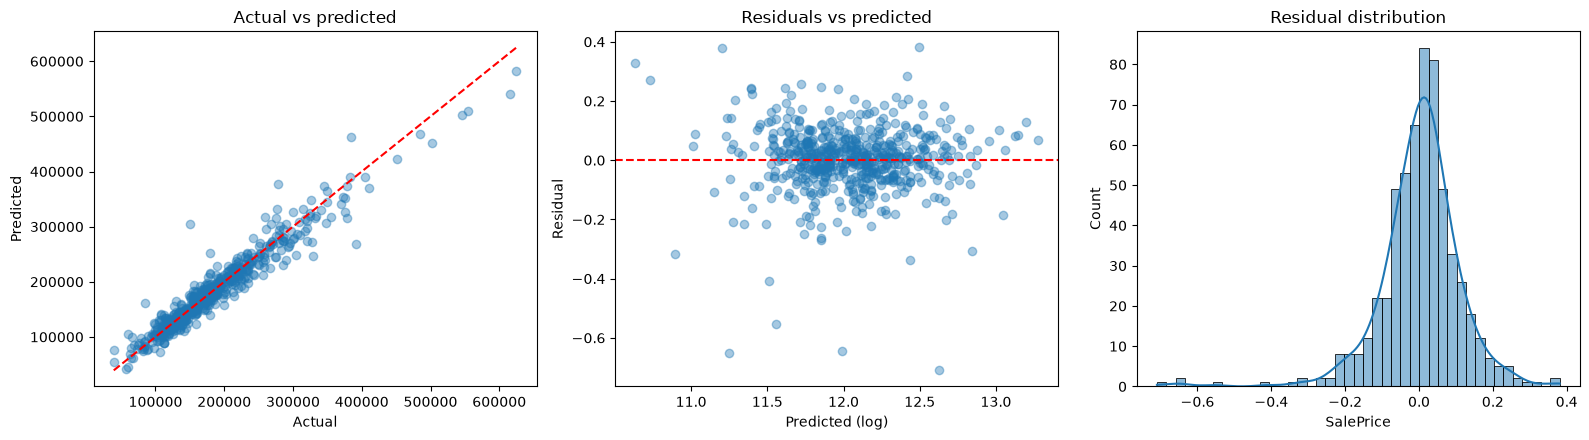

In [86]:
best_model = models[best_name]
pred_log = best_model.predict(X_test)
resid_log = y_test_log - pred_log

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(y_test, np.expm1(pred_log), alpha=0.4)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "r--")
ax[0].set(xlabel="Actual", ylabel="Predicted", title="Actual vs predicted")

ax[1].scatter(pred_log, resid_log, alpha=0.4)
ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="Predicted (log)", ylabel="Residual", title="Residuals vs predicted")

sns.histplot(resid_log, kde=True, ax=ax[2]); ax[2].set_title("Residual distribution")
plt.tight_layout(); plt.show()

Kept 120 of 273 features


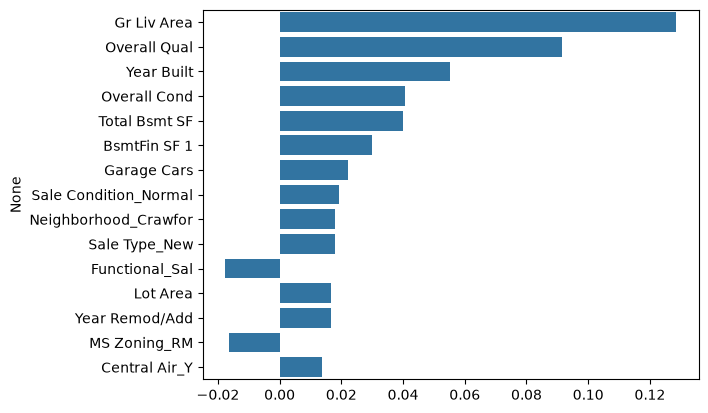

In [87]:
lasso = models["Lasso"][-1]
coefs = pd.Series(lasso.coef_, index=X.columns)
print(f"Kept {(coefs != 0).sum()} of {len(coefs)} features")

top = coefs[coefs != 0].sort_values(key=np.abs, ascending=False).head(15)
sns.barplot(x=top.values, y=top.index, orient="h"); plt.show()

In [88]:
final_model = TransformedTargetRegressor(
    regressor=clone(models[best_name]),      
    func=np.log1p,
    inverse_func=np.expm1,
)
final_model.fit(X, y)

,regressor,Pipeline(step...0000e+03])))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,copy,True
,with_mean,True
,with_std,True
,alphas,array([1.0000...00000000e+03])
,fit_intercept,True
,scoring,None


In [91]:
joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")

# verify the saved file works
loaded_model = joblib.load("house_price_model.pkl")
loaded_cols  = joblib.load("model_columns.pkl")

sample = X.iloc[:5][loaded_cols]
assert np.allclose(final_model.predict(sample), loaded_model.predict(sample))
print(loaded_model.predict(sample).round(0))
print(y.iloc[:5].values)

[206184. 119059. 161996. 260241. 181568.]
[215000 105000 172000 244000 189900]
